# Dryguard · 01 — Explore RFID moisture data

**Our first question:** what do these recordings actually let us compare?

We want eventually to detect whether laundry is dry using RFID. Today we are
learning with a small public **soil-moisture** dataset. We will load real
measurements, check their labels, and visualize RSSI. No classifier is trained
in this notebook.

**Learning goals:** distinguish a read from an experiment; identify a confounder;
explain why an apparently good train/test score can be misleading.

The 60 unmodified CSVs are bundled with this project. Run each cell in order.
Source: [Wireless Information Networking Group, UAB](https://github.com/Wireless-Information-Networking/RFID-Reader-FX7500),
commit `790b419e86b508c38487d679658a8bad266237be`.
See `docs/DATA_CARD.md` for selection, attribution, and limitations.

## 1. Load the recordings

`pandas` gives us tables, `numpy` handles numbers, and `matplotlib` makes plots.
Each CSV contains many repeated RFID reads. We retain its filename and session
so we can keep related observations together later.

In [1]:
# Path helps us work with file and folder locations.
from pathlib import Path
# json reads the manifest: a structured list describing our data files.
import json
# NumPy provides numerical tools; np is its short name, used later in the notebook.
import numpy as np
# pandas works with tables called DataFrames; pd is its short name.
import pandas as pd
# pyplot provides plotting tools; plt is its short name, used later in the notebook.
import matplotlib.pyplot as plt
# display shows a neatly formatted table in the notebook.
from IPython.display import display

# Get the folder that Python is currently running from.
ROOT = Path.cwd()
# Check whether this folder is missing the data manifest; / joins parts of a path.
if not (ROOT / "data/manifest.json").exists():
    # If it is missing, try the parent folder (useful when running from notebooks/).
    ROOT = ROOT.parent
# Stop with this message if the manifest is still missing.
assert (ROOT / "data/manifest.json").exists(), "Run from the project root or notebooks folder."
# Read the manifest file and convert its JSON text into Python dictionaries and lists.
manifest = json.loads((ROOT / "data/manifest.json").read_text())

# Start an empty list that will hold one table per CSV recording.
frames = []
# Loop through every recording listed in the manifest.
for item in manifest["files"]:
    # Build the full path to this recording’s CSV file.
    path = ROOT / item["local_path"]
    # Check whether that CSV file is missing.
    if not path.exists():
        # If missing, stop and show the command that can restore the data.
        raise FileNotFoundError("Restore the CSVs with: python scripts/download_data.py")
    # Load this CSV into a table; skip spaces after commas. Each row is one RFID read.
    part = pd.read_csv(path, skipinitialspace=True)
    # Remove leading and trailing spaces from the column names.
    part.columns = part.columns.str.strip()
    # Loop through columns with object dtype (the text columns in these CSVs).
    for column in part.select_dtypes(include="object"):
        # Remove leading and trailing spaces from the text values in this column.
        part[column] = part[column].str.strip()
    # Attach the recording’s source path to every row so we can trace each read.
    part["source_file"] = item["source_path"]
    # Attach its session for tracking and checking comparisons; this is not a model input.
    part["session"] = item["session"]
    # Add this recording’s table to our list of tables.
    frames.append(part)

# Stack all recording tables into df; give the combined rows a fresh numeric index.
df = pd.concat(frames, ignore_index=True)
# Print the number of recordings and reads; :, formats the read count with commas.
print(f"{len(frames)} recordings · {len(df):,} reader events")
# Show selected columns for only the first five reads. head() is a preview, not an average.
display(df[["peakRssi", "phase", "power", "pos_y", "moist", "obs", "session"]].head())


Matplotlib is building the font cache; this may take a moment.


60 recordings · 54,537 reader events


,peakRssi,phase,power,pos_y,moist,obs,session
0,-45,-148.704483,28,1.543,0.01,Soil_(Dry),2025-02-28b
1,-45,-150.132751,28,1.543,0.01,Soil_(Dry),2025-02-28b
2,-45,-148.265030,28,1.543,0.01,Soil_(Dry),2025-02-28b
3,-45,-149.764709,28,1.543,0.01,Soil_(Dry),2025-02-28b
4,-45,-148.210083,28,1.543,0.01,Soil_(Dry),2025-02-28b


## 2. Check the labels before using them

`peakRssi` is received signal strength in dBm. For example, −40 dBm is stronger
than −60 dBm. `power` is the transmitter setting, which can also change RSSI.

We derive our label from the authors' exact `obs` condition. We keep `moist`
as reported metadata; we have not independently calibrated it. These labels
are experimental soil conditions, not a definition of dry laundry.

In [2]:
label_map = {"Soil_(Dry)": "dry", "Soil_(Wet)": "wet"}
assert df["obs"].isin(label_map).all(), "Unexpected condition: inspect before labeling."
df["label"] = df["obs"].map(label_map)
filename_label = df["source_file"].str.extract(r"Soil_\((Dry|Wet)\)", expand=False).str.lower()
assert df["label"].eq(filename_label).all(), "Filename and recorded condition disagree."

required = ["peakRssi", "phase", "channel", "pos_y", "depth", "moist", "time_reader", "power", "obs"]
missing = df[required].isna().sum()
display(missing.rename("missing_values").to_frame())
assert missing.sum() == 0
numeric = [c for c in required if c != "obs"]
assert np.isfinite(df[numeric].to_numpy(dtype=float)).all()

source_columns = [c for c in df if c not in {"source_file", "session", "label"}]
print("Exact duplicate source rows:", df.duplicated(source_columns).sum())
print("Tag types:", df["tag"].unique().tolist())
print("Antennas:", df["antenna"].unique().tolist())
print("Channels (MHz):", df["channel"].unique().tolist())

,missing_values
peakRssi,0
phase,0
channel,0
pos_y,0
depth,0
moist,0
time_reader,0
power,0
obs,0


Exact duplicate source rows: 0
Tag types: ['Dogbone_Monza_4D']
Antennas: [1]
Channels (MHz): [865.7]


## 3. Give each recording one row

A 60-second file can contain far more reads than a 5-second file. Pooling every
read would give longer files more influence. We use each recording's median
RSSI for our first plots. Median means the middle value after sorting.

The observed read span below is the time between the first and last recorded
reads. It does **not** establish how long the reader was commanded to scan.

In [3]:
settings = ["label", "session", "moist", "power", "pos_y", "depth", "channel", "antenna", "tag"]
constant_counts = df.groupby("source_file")[settings].nunique(dropna=False)
assert constant_counts.le(1).all().all(), "Some files contain changing conditions; split them first."

recordings = df.groupby("source_file", sort=True).agg(
    session=("session", "first"), label=("label", "first"),
    reported_moisture=("moist", "first"), power_dbm=("power", "first"),
    position_y_m=("pos_y", "first"), n_reads=("peakRssi", "size"),
    rssi_median_dbm=("peakRssi", "median"),
    rssi_q25_dbm=("peakRssi", lambda x: x.quantile(0.25)),
    rssi_q75_dbm=("peakRssi", lambda x: x.quantile(0.75)),
    first_read=("time_reader", "min"), last_read=("time_reader", "max")
).reset_index()
recordings["observed_read_span_s"] = recordings["last_read"] - recordings["first_read"]

summary = recordings.groupby(["session", "label"]).agg(
    files=("source_file", "size"), reads=("n_reads", "sum"),
    median_of_file_rssi_dbm=("rssi_median_dbm", "median"),
    min_power_dbm=("power_dbm", "min"), max_power_dbm=("power_dbm", "max"),
    min_position_m=("position_y_m", "min"), max_position_m=("position_y_m", "max")
)
display(summary)
print("Observed read span (seconds):",
      recordings["observed_read_span_s"].min().round(3), "to",
      recordings["observed_read_span_s"].max().round(3))
(ROOT / "reports").mkdir(exist_ok=True)
recordings.to_csv(ROOT / "reports/recording_summary.csv", index=False)

,,files,reads,median_of_file_rssi_dbm,min_power_dbm,max_power_dbm,min_position_m,max_position_m
session,label,,,,,,,
2025-02-28b,dry,12,8844,-43.0,10,29,0.178,1.543
2025-03-06a,wet,12,7520,-53.5,10,27,0.183,0.572
2025-03-06b,wet,12,8864,-48.0,10,29,0.075,1.541
2025-03-07a,wet,12,9022,-50.0,10,29,0.093,1.543
2025-03-11b,wet,12,20287,-46.0,10,29,0.204,1.543


Observed read span (seconds): 0.086 to 60.535


## 3a. Compare recordings with similar settings

Run sections 1–3 first. **Here one row is one recording**, summarized from many reads.
The median is the middle RSSI value. The IQR measures spread within a recording:
75th percentile minus 25th percentile. An IQR of zero can occur when many reads
share the same integer RSSI; it does not prove there is no measurement uncertainty.

We compare every dry/wet pair at the same transmit power, then keep positions
within **5 cm** as an exploratory filter. This tolerance is not experimentally
validated. A recording may appear in several pairs, so pairs are not independent.
The pair selection does not use RSSI, avoiding selection for a desired result.

Matching power and `pos_y` improves comparability but does not establish a moisture
effect: sessions still differ, and this does not match every aspect of geometry or
verify an unchanged physical setup. Positive `wet_minus_dry_db` means wet had a
stronger signal; negative means wet had a weaker signal. Neither sign proves causation.

The 5 cm cutoff includes its boundary; numerical rounding prevents a recorded
5 cm difference from being excluded by floating-point arithmetic.


In [4]:
# Copy the recording summaries so this learning table can be edited independently.
comparison = recordings.copy()
# The interquartile range (IQR) is the width of the middle 50% of reads, not uncertainty in the median.
comparison["rssi_iqr_db"] = comparison["rssi_q75_dbm"] - comparison["rssi_q25_dbm"]
# Sort by power and position to make similar measurement settings easier to spot.
comparison = comparison.sort_values(["power_dbm", "position_y_m", "label", "source_file"])
# Choose the columns to show; source_file remains available in the saved full table.
view_columns = ["label", "session", "reported_moisture", "power_dbm", "position_y_m", "n_reads", "rssi_median_dbm", "rssi_iqr_db"]
# Show all recording summaries: each row here represents one CSV, unlike a row in df.
display(comparison[view_columns].reset_index(drop=True))
# Save the full comparison with recording identifiers for traceability.
comparison.to_csv(ROOT / "reports/recording_comparison.csv", index=False)

# Separate dry recordings from wet recordings before pairing their settings.
dry = comparison.loc[comparison["label"].eq("dry")]
# Each wet row still represents a whole recording.
wet = comparison.loc[comparison["label"].eq("wet")]
# Form every dry/wet pair with exactly the same recorded transmit power; recordings can appear in several pairs.
pairs = dry.merge(wet, on="power_dbm", suffixes=("_dry", "_wet"))
# Measure the position gap in metres; rounding removes floating-point noise at the 5 cm boundary.
pairs["position_gap_m"] = (pairs["position_y_m_wet"] - pairs["position_y_m_dry"]).abs().round(9)
# Compare medians: positive means the wet recording had a stronger received signal.
pairs["wet_minus_dry_db"] = pairs["rssi_median_dbm_wet"] - pairs["rssi_median_dbm_dry"]
# Sort only by setting similarity and identifiers, never by the signal difference we hope to find.
pairs = pairs.sort_values(["position_gap_m", "power_dbm", "source_file_dry", "source_file_wet"])
# Use 5 cm as an exploratory filter, not a proven tolerance for equivalent radio conditions.
position_tolerance_m = 0.05
# Keep all same-power pairs whose recorded positions differ by at most 5 cm.
near_pairs = pairs.loc[pairs["position_gap_m"].le(position_tolerance_m)].copy()
# Report exact recorded-position matches separately from approximate matches.
print("Same-power pairs with exactly matching recorded position:", int(pairs["position_gap_m"].eq(0).sum()))
# Pair counts are comparisons, not counts of independent experiments.
print("Same-power pairs within 5 cm:", len(near_pairs))
# Show the settings, moisture, signal medians, variation and sessions for each candidate pair.
pair_columns = ["power_dbm", "position_y_m_dry", "position_y_m_wet", "position_gap_m", "reported_moisture_wet", "rssi_median_dbm_dry", "rssi_median_dbm_wet", "wet_minus_dry_db", "rssi_iqr_db_dry", "rssi_iqr_db_wet", "session_dry", "session_wet"]
# An empty table means this subset has no pairs within our exploratory tolerance.
display(near_pairs[pair_columns].reset_index(drop=True))
# Save all same-power pairs, including those farther apart, so the filter can be audited.
pairs.to_csv(ROOT / "reports/same_power_pairs.csv", index=False)
# Keep the subset of close-position candidates in a separate report.
near_pairs.to_csv(ROOT / "reports/near_position_pairs.csv", index=False)


,label,session,reported_moisture,power_dbm,position_y_m,n_reads,rssi_median_dbm,rssi_iqr_db
0,wet,2025-03-06b,0.12,10,0.075,789,-36.0,0.0
1,wet,2025-03-07a,0.18,10,0.093,837,-38.0,1.0
2,wet,2025-03-06a,0.06,10,0.183,809,-46.0,0.0
3,wet,2025-03-06a,0.06,10,0.249,36,-41.0,1.0
4,wet,2025-03-11b,0.24,10,0.431,35,-42.0,0.0
5,dry,2025-02-28b,0.01,10,0.519,814,-46.0,0.0
6,wet,2025-03-06a,0.06,10,0.572,18,-63.0,0.0
7,wet,2025-03-11b,0.24,10,1.100,50,-53.0,0.0
8,wet,2025-03-06b,0.12,10,1.146,23,-56.0,0.5
9,wet,2025-03-07a,0.18,10,1.198,16,-55.0,0.0


Same-power pairs with exactly matching recorded position: 0
Same-power pairs within 5 cm: 1


,power_dbm,position_y_m_dry,position_y_m_wet,position_gap_m,reported_moisture_wet,rssi_median_dbm_dry,rssi_median_dbm_wet,wet_minus_dry_db,rssi_iqr_db_dry,rssi_iqr_db_wet,session_dry,session_wet
0,16,0.478,0.528,0.05,0.12,-43.0,-51.0,-8.0,1.0,0.0,2025-02-28b,2025-03-06b


## 3b. Add six source-verified wet recordings for exact setting matches

Run section 1 first to load the libraries and define `ROOT`. This section uses a
separate manifest, `data/matched/manifest.json`: **four existing dry recordings and
six additional wet recordings** form six comparisons. Two dry recordings are
reused. The original 60-recording exploration remains a separate subset.

The extra wet files were selected from the same pinned source commit by matching
power and position to our existing dry recordings, without using RSSI to choose
them. Every CSV is checked against its Git blob hash. Within each pair, recorded
power, `pos_y`, tag type, frequency, antenna index and depth must match. This does
not verify every aspect of geometry or guarantee an unchanged physical setup.

**How to read the plots:** the x-axis is RSSI (farther right means stronger).
The y-axis gives the fraction of that recording's reads at or below each RSSI.
The dotted 0.5 line marks the middle of the distribution. These are empirical
cumulative distribution functions (ECDFs); repeated identical values make jumps.

Sessions still differ in every pair, and all dry files are from one session.
These are six descriptive comparisons, not six independent moisture experiments.
The curves are distributions of repeated reads, not confidence intervals.


,pair_id,power_dbm,position_y_m,dry_moisture,wet_moisture,dry_median_dbm,wet_median_dbm,wet_minus_dry_db,dry_session,wet_session
0,1,16.0,0.478,0.01,0.12,-43.0,-50.0,-7.0,2025-02-28b,2025-03-06b
1,2,26.0,0.800,0.01,0.18,-43.0,-55.0,-12.0,2025-02-28b,2025-03-07a
2,3,26.0,0.800,0.01,0.24,-43.0,-51.0,-8.0,2025-02-28b,2025-03-11b
3,4,28.0,1.355,0.01,0.24,-45.0,-55.0,-10.0,2025-02-28b,2025-03-11b
4,5,28.0,1.543,0.01,0.18,-45.0,-60.0,-15.0,2025-02-28b,2025-03-07a
5,6,28.0,1.543,0.01,0.24,-45.0,-56.0,-11.0,2025-02-28b,2025-03-11b


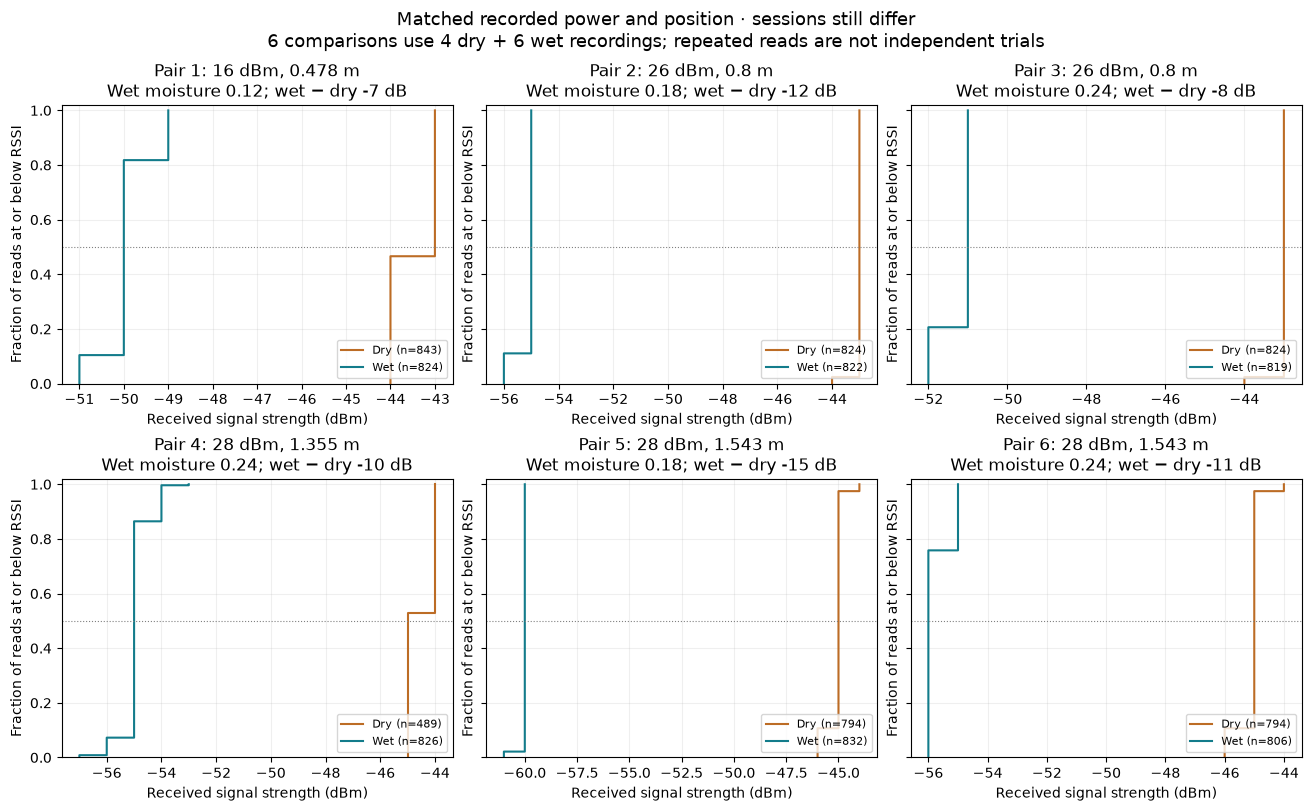

In [5]:
# hashlib lets us check that each CSV still matches the original source file.
import hashlib
# Read the separate manifest describing ten unique recordings and six comparisons.
matched_manifest = json.loads((ROOT / "data/matched/manifest.json").read_text())
# Store each recording by its source filename; repeated dry files are loaded only once.
matched_data = {}
# Load and verify each recording listed in the matched manifest.
for item in matched_manifest["files"]:
    # Read the original bytes before interpreting them as a table.
    raw_bytes = (ROOT / item["local_path"]).read_bytes()
    # Git hashes a header plus the file bytes; reproduce that format to verify provenance.
    blob_hash = hashlib.sha1(b"blob " + str(len(raw_bytes)).encode() + b"\0" + raw_bytes).hexdigest()
    # Stop if the local file differs from the pinned source.
    assert blob_hash == item["blob_sha"], f"Source file changed: {item['local_path']}"
    # Read this recording into a pandas table.
    table = pd.read_csv(ROOT / item["local_path"], skipinitialspace=True)
    # Remove padding around the column names.
    table.columns = table.columns.str.strip()
    # Find text columns that may also contain padded values.
    for column in table.select_dtypes(include="object"):
        # Remove spaces and tabs around text values.
        table[column] = table[column].str.strip()
    # Check that every row has the expected source condition.
    assert table["obs"].eq({"dry": "Soil_(Dry)", "wet": "Soil_(Wet)"}[item["label"]]).all()
    # Ensure RSSI values are valid numbers before calculating summaries.
    assert np.isfinite(table["peakRssi"].to_numpy(dtype=float)).all()
    # Remember the collection session as provenance, not as a model feature.
    table["session"] = item["session"]
    # Retain the table for the later pairing loop.
    matched_data[item["source_path"]] = table

# Collect one summary row for each comparison, not for each reader event.
matched_rows = []
# Make six plot panels, one for each preselected dry/wet comparison.
matched_fig, matched_axes = plt.subplots(2, 3, figsize=(13, 8), layout="constrained", sharey=True)
# Pair each panel with its comparison metadata.
for ax, pair in zip(matched_axes.flat, matched_manifest["pairs"]):
    # Retrieve the complete dry recording for this comparison.
    dry_reads = matched_data[pair["dry_file"]]
    # Retrieve the complete wet recording for this comparison.
    wet_reads = matched_data[pair["wet_file"]]
    # Check the recorded settings that we claim are matched.
    for setting in ["power", "pos_y", "tag", "channel", "antenna", "depth"]:
        # Each recording must have one value, and both recordings must agree.
        assert dry_reads[setting].nunique(dropna=False) == wet_reads[setting].nunique(dropna=False) == 1
        # Compare the actual values, not just their number.
        assert dry_reads[setting].iloc[0] == wet_reads[setting].iloc[0], setting
    # Confirm the matched power agrees with the manifest.
    assert dry_reads["power"].iloc[0] == pair["power_dbm"]
    # Confirm the matched position agrees with the manifest.
    assert dry_reads["pos_y"].iloc[0] == pair["position_y_m"]
    # Get the dry recording's middle RSSI value.
    dry_median = dry_reads["peakRssi"].median()
    # Get the wet recording's middle RSSI value.
    wet_median = wet_reads["peakRssi"].median()
    # Keep pair identifiers and settings with the descriptive results.
    row = dict(pair)
    # Add each recording's moisture, session, read count and spread to the summary.
    for label, table in [("dry", dry_reads), ("wet", wet_reads)]:
        # Check that the recorded moisture value is constant within this recording.
        assert table["moist"].nunique(dropna=False) == 1
        # Save the source moisture value without converting it into a percentage.
        row[f"{label}_moisture"] = table["moist"].iloc[0]
        # Preserve the session so the remaining mismatch is visible.
        row[f"{label}_session"] = table["session"].iloc[0]
        # Count reader events; these are repeated observations, not independent trials.
        row[f"{label}_reads"] = len(table)
        # Save the median RSSI for this recording.
        row[f"{label}_median_dbm"] = table["peakRssi"].median()
        # IQR measures the spread of the middle half of reads, not confidence in the median.
        row[f"{label}_iqr_db"] = table["peakRssi"].quantile(0.75) - table["peakRssi"].quantile(0.25)
    # A negative difference means the wet recording had a weaker median signal.
    row["wet_minus_dry_db"] = wet_median - dry_median
    # Append this comparison to the summary table.
    matched_rows.append(row)
    # Plot sorted readings as empirical cumulative distributions, retaining all observations.
    for label, table, color in [("Dry", dry_reads, "#bc6c25"), ("Wet", wet_reads, "#137c8b")]:
        # Sort signal strengths from weakest to strongest.
        signal = np.sort(table["peakRssi"].to_numpy())
        # Each step gives the fraction of this recording's reads at or below that strength.
        fraction = np.arange(1, len(signal) + 1) / len(signal)
        # An ECDF avoids choosing arbitrary histogram bins and gives recordings equal visual weight.
        ax.step(signal, fraction, where="post", color=color, label=f"{label} (n={len(signal)})")
    # Mark the 50% level used to read a median from each curve.
    ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.8)
    # Identify settings and wet moisture without suggesting the sessions are matched.
    ax.set_title(f"Pair {pair['pair_id']}: {pair['power_dbm']:g} dBm, {pair['position_y_m']:g} m\nWet moisture {row['wet_moisture']:g}; wet − dry {row['wet_minus_dry_db']:g} dB")
    # Label both axes with their meaning and units.
    ax.set(xlabel="Received signal strength (dBm)", ylabel="Fraction of reads at or below RSSI", ylim=(0, 1.02))
    # Light guide lines make proportions easier to compare.
    ax.grid(alpha=0.2)
    # Show the condition and read count for each curve.
    ax.legend(loc="lower right", fontsize=8)
# State the main limitation directly on the figure.
matched_fig.suptitle("Matched recorded power and position · sessions still differ\n6 comparisons use 4 dry + 6 wet recordings; repeated reads are not independent trials", fontsize=13)
# Convert the comparison summaries into one table.
matched_summary = pd.DataFrame(matched_rows)
# Show the main comparison columns, including sessions.
display(matched_summary[["pair_id", "power_dbm", "position_y_m", "dry_moisture", "wet_moisture", "dry_median_dbm", "wet_median_dbm", "wet_minus_dry_db", "dry_session", "wet_session"]])
# Save the full summary, including source filenames and within-recording variation.
matched_summary.to_csv(ROOT / "reports/matched_recordings.csv", index=False)
# Save a standalone plot for inspection and sharing.
matched_fig.savefig(ROOT / "reports/matched_distributions.png", dpi=150, facecolor="white")
# Display the figure in the notebook.
plt.show()


### What these matched recordings show

Wet median RSSI is 7–15 dB weaker in the six selected comparisons. This pattern
is descriptive: different sessions and possible setup differences remain.
Higher reported moisture does not consistently give weaker RSSI (compare pairs
2 and 3, or pairs 5 and 6). These data do not establish a monotonic moisture sensor.
No classifier or accuracy claim is added.


## 4. Look for a hidden shortcut

A **confounder** changes alongside what we want to study. Here the recording
session changes with the wet/dry label. The table counts files, not reads.

In [6]:
session_labels = pd.crosstab(recordings["session"], recordings["label"])
display(session_labels)
print("Sessions containing both wet and dry files:",
      int(session_labels.gt(0).all(axis=1).sum()))

label,dry,wet
session,,
2025-02-28b,12,0
2025-03-06a,0,12
2025-03-06b,0,12
2025-03-07a,0,12
2025-03-11b,0,12


Sessions containing both wet and dry files: 0


All 12 dry files belong to one session. All 48 wet files belong to four later
sessions. A model might learn signal differences caused by the setup or day.
Simply hiding the `session` column does not remove those differences from RSSI.

A random split of individual reads is especially misleading because reads
from the same file could appear on both sides. Keeping files together avoids
that problem, but it still would not establish performance on new sessions.
Holding out the only dry session leaves no dry examples in training.

**Pause:** if a classifier scored 99% after randomly splitting the rows, what
would that score tell us about a new dryer run?

## 5. Inspect RSSI and the changing settings

Each point below represents one recording. Left: median RSSI across sessions.
Right: median RSSI versus recorded position, colored by transmit power.
Neither plot isolates the effect of moisture.

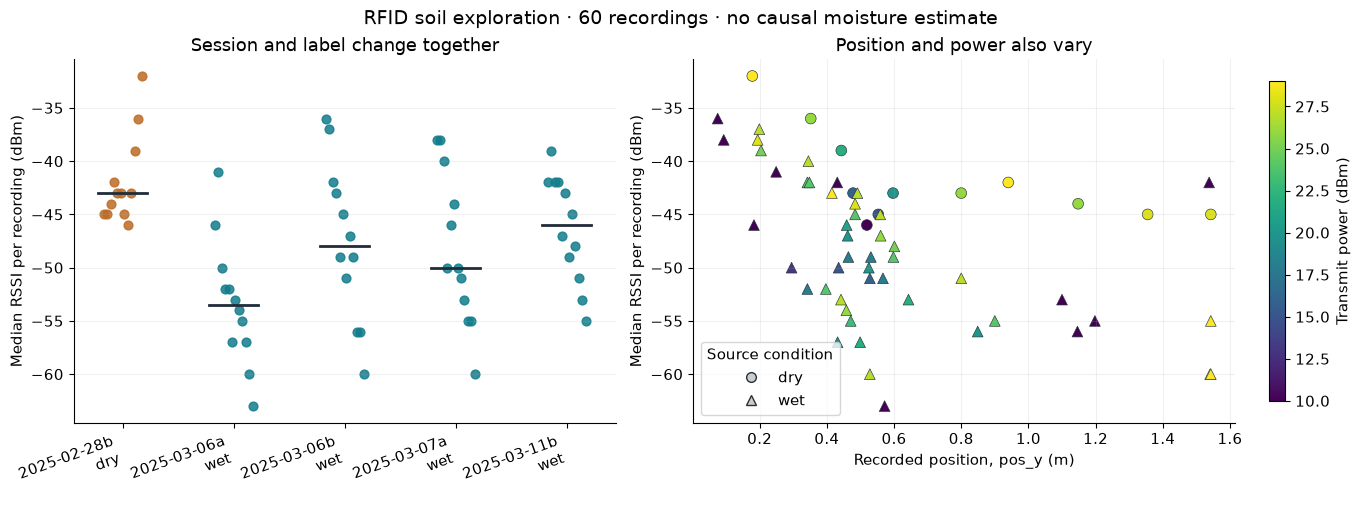

In [7]:
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5), layout="constrained")
sessions = sorted(recordings["session"].unique())
colors = {"dry": "#bc6c25", "wet": "#137c8b"}
for i, session in enumerate(sessions):
    subset = recordings.loc[recordings["session"].eq(session)]
    label = subset["label"].iloc[0]
    jitter = np.linspace(-0.17, 0.17, len(subset))
    axes[0].scatter(i + jitter, subset["rssi_median_dbm"],
                    color=colors[label], s=40, alpha=0.85)
    median = subset["rssi_median_dbm"].median()
    axes[0].plot([i-0.22, i+0.22], [median, median], color="#202c39", lw=2)
axes[0].set_xticks(range(len(sessions)),
    [s + "\n" + recordings.loc[recordings["session"].eq(s), "label"].iloc[0] for s in sessions],
    rotation=20, ha="right")
axes[0].set(ylabel="Median RSSI per recording (dBm)", title="Session and label change together")
axes[0].grid(axis="y", alpha=0.18)

for label, marker in [("dry", "o"), ("wet", "^")]:
    subset = recordings.loc[recordings["label"].eq(label)]
    scatter = axes[1].scatter(subset["position_y_m"], subset["rssi_median_dbm"],
        c=subset["power_dbm"], cmap="viridis", vmin=10, vmax=29,
        marker=marker, s=60, edgecolors="#263238", linewidths=0.45, label=label)
axes[1].set(xlabel="Recorded position, pos_y (m)", ylabel="Median RSSI per recording (dBm)",
            title="Position and power also vary")
axes[1].grid(alpha=0.18)
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], marker=marker, color="none", markerfacecolor="#cccccc",
                 markeredgecolor="#263238", markersize=7, label=label)
           for label, marker in [("dry", "o"), ("wet", "^")]]
axes[1].legend(handles=handles, title="Source condition", loc="lower left")
fig.colorbar(scatter, ax=axes[1], label="Transmit power (dBm)", shrink=0.88)
fig.suptitle("RFID soil exploration · 60 recordings · no causal moisture estimate", fontsize=14)
fig.savefig(ROOT / "reports/rfid_exploration.png", dpi=160, facecolor="white")
plt.show()

**Reading the plots:** the distributions overlap and the acquisition settings
differ. A difference between two session medians is not a measured moisture
effect. Equal weighting of recordings helps with unequal file lengths; it
does not make these recordings independent or remove confounding.

## 6. Zoom into one recording

This is a signal trace within one labeled condition. It is not a drying curve.
The example is chosen deterministically as the middle filename within the dry
session; change the index to inspect a different recording.

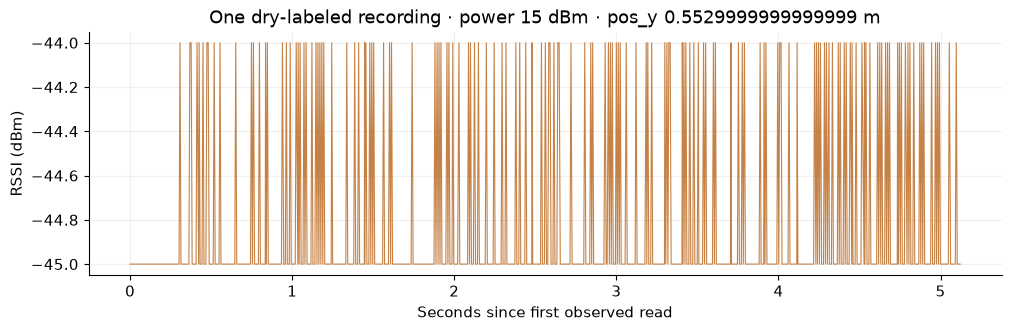

20250228_200654gui_Dogbone_Monza_4D_865.7MHz_0.5529999999999999m_Soil_(Dry).csv


In [8]:
example_file = recordings.loc[recordings["label"].eq("dry"), "source_file"].iloc[6]
example = df.loc[df["source_file"].eq(example_file)].sort_values("time_reader")
elapsed = example["time_reader"] - example["time_reader"].iloc[0]
fig, ax = plt.subplots(figsize=(10, 3.2), layout="constrained")
ax.plot(elapsed, example["peakRssi"], lw=0.8, color="#bc6c25", alpha=0.85)
ax.set(xlabel="Seconds since first observed read", ylabel="RSSI (dBm)",
       title=f"One dry-labeled recording · power {example['power'].iloc[0]} dBm · pos_y {example['pos_y'].iloc[0]} m")
ax.grid(alpha=0.18)
plt.show()
print(Path(example_file).name)

## Your first two exercises

1. Inspect `recordings[["label", "power_dbm", "position_y_m", "rssi_median_dbm"]]`.
   Find wet and dry recordings with the same power. Are their positions also
   close? What else still differs?
2. Change the example recording above. Does stronger RSSI by itself prove that
   the material is drier? Use the measurement settings to explain your answer.

## Our next milestone

Before comparing RSSI-only and RSSI-plus-phase classifiers, audit a larger
subset for matching settings and independent dry/wet sessions. Keep source
files grouped in any train/test split and state exactly what the split tests.
Treat phase as circular: a later model can use `sin(phase)` and `cos(phase)`
after converting degrees to radians. Never use `moist`, `obs`, filenames, or
session identifiers as signal features.

For the laundry goal, we will need textile measurements paired with an
independent moisture reference and held-out complete drying cycles.

**Current result:** a reproducible dataset audit and signal exploration. No
training, accuracy estimate, or validated laundry detector yet.